In [25]:
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

if os.getenv("OPENAI_API_KEY") is None:
    raise ValueError("OPENAI_API_KEY environment variable is not set")
else:
    print("OPENAI_API_KEY environment variable is set")

OPENAI_API_KEY environment variable is set


In [9]:
llm = ChatOpenAI(
    model_name="gpt-5-nano",
    temperature=0.7
)

response = llm.invoke("Hello, how are you?")

print(response.content)


Hello! I’m here and ready to help with whatever you need. I don’t have feelings, but I’m functioning well. How can I assist you today?


### ***1- Pydantic Schema***


In [ ]:
from pydantic import BaseModel, Field

class Graph_Schema(BaseModel):
    topic: str = Field(description="The topic of the conversation")
    post: str = Field(description="The linkedin post to be made on the topic")
    curated_post: str = Field(description="The curated version of the linkedin post")

demo_obj = Graph_Schema(
    topic="AI in Healthcare",
    post="Excited to share the latest advancements in AI in healthcare! Check out this article on how AI is transforming the industry.",
    curated_post="Excited to share the latest advancements in AI in healthcare! Check out this article on how AI is transforming the industry."
)

print(demo_obj)

topic='AI in Healthcare' post='Excited to share the latest advancements in AI in healthcare! Check out this article on how AI is transforming the industry.' curated_post='Excited to share the latest advancements in AI in healthcare! Check out this article on how AI is transforming the industry.'


### ***Step-2 Create The Node Functions***

In [21]:
def create_post(state: Graph_Schema) -> Graph_Schema:
    # Convert the Pydantic model to a dictionary
    state = state.model_dump()

    # Get the topic from the dictionary
    topic = state["topic"]

    # Passing the topic to create the linkedin post
    post = llm.invoke(f"Excited to share the latest advancements in {topic}! Check out this article on how AI is transforming the industry.").content
    state["post"] = post

    return state

def curate_post(state: Graph_Schema) -> Graph_Schema:
    # Convert the Pydantic model to a dictionary
    state = state.model_dump()

    # Get the post from the dictionary
    post = state["post"]

    # Passing the post to curate the linkedin post
    curated_post = llm.invoke(f"Please curate the following linkedin post: {post}").content
    state["curated_post"] = curated_post

    return state


### ***Step-3 Create The State Graph***

In [22]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(Graph_Schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

### ***Step-4 Compile Graph***

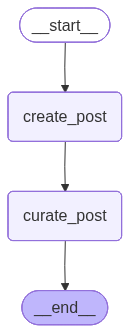

In [23]:
from IPython.display import Image, display

first_compiled_graph = graph.compile()

Image(first_compiled_graph.get_graph().draw_mermaid_png())

# You could see the error with the below command to see graph without error
#print(first_compiled_graph.get_graph().draw_mermaid())

### ***Step-4 Run Graph***

In [24]:
first_compiled_graph.invoke({"topic": "The importance of data privacy in digital age", "post" : "","curated_post": ""})

{'topic': 'The importance of data privacy in digital age',
 'post': 'That sounds great! If you share the article link or paste the text, I can give you a concise summary and key takeaways. Meanwhile, here are the core themes you’ll typically see in pieces about data privacy and AI:\n\n- Why data privacy matters in the AI era: AI relies on large datasets, which heightens privacy risks and the impact of breaches or misuse.\n- AI-driven transformations across industries: personalized services, automation, and data-driven decision-making—and the privacy trade-offs they entail.\n- Privacy-preserving techniques gaining traction: differential privacy, federated learning, secure multi-party computation, synthetic data, and on-device processing.\n- Data governance basics: data minimization, purpose limitation, consent management, data provenance, access controls, and retention policies.\n- Regulatory and risk landscape: GDPR, CCPA/CPRA, LGPD, and the need for DPIAs (data protection impact asses